# 02 - Meteorite Bulk Composition

This notebook demonstrates how to process meteorite bulk compositions and compare them with planetary compositions.

It covers:
- Converting wt% to molar amounts using `Elements` molar masses
- Normalizing to MgO (molar ratio)
- Applying enrichment/depletion corrections to EF composition
- Normalizing to Mg and CI chondrites (mantle & core separately)
- Visualizing bulk compositions as a CI-normalized spider diagram
- Exporting the results to CSV

> **Prerequisites:** Run `01_constants_and_setup.ipynb` first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150
})
Colors = {
    'Earth': "#1f77b4",
    'Mars' : "#d62728",
    'EF'   : "#8c564b",
    'EC'   : "#ff7f0e",
    'OC'   : "#2ca02c",
    'CI'   : "#9467bd",
}

# ── Load constants ───────────────────────────────────────
Elements = ad.constants.Elements
EF_bulk  = ad.constants.EF_bulk
EC_bulk  = ad.constants.EC_bulk
OC_bulk  = ad.constants.OC_bulk
CI_bulk  = ad.constants.CI_bulk

# ── Compute molar masses for oxides & metals ─────────────
calc = ad.MolarMassCalculator(mass_table=Elements)
compounds = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']
for c in compounds:
    Elements[c] = calc.molar_mass(c)

mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items   = ['Fe', 'Ni', 'Si', 'O']
bulk_items   = mantle_items + core_items

print("Setup complete.")

Setup complete.


## 1. Convert wt% to Molar Amounts

Molar amount is calculated as:

$$n_i = \frac{w_i}{M_i}$$

where $w_i$ is the weight percent and $M_i$ is the molar mass (g/mol).

If a component is absent in a meteorite type, it is set to `NaN` and later replaced by `0`.

In [2]:
# Convert weight percentages to molar amounts
EF_bulk_molar, EC_bulk_molar, OC_bulk_molar, CI_bulk_molar = {}, {}, {}, {}

for item in bulk_items:
    EF_bulk_molar[item] = EF_bulk[item] / Elements[item] if item in EF_bulk and Elements[item] else np.nan
    EC_bulk_molar[item] = EC_bulk[item] / Elements[item] if item in EC_bulk and Elements[item] else np.nan
    OC_bulk_molar[item] = OC_bulk[item] / Elements[item] if item in OC_bulk and Elements[item] else np.nan
    CI_bulk_molar[item] = CI_bulk[item] / Elements[item] if item in CI_bulk and Elements[item] else np.nan

df_molar = pd.DataFrame({
    'EF': EF_bulk_molar,
    'EC': EC_bulk_molar,
    'OC': OC_bulk_molar,
    'CI': CI_bulk_molar,
}).fillna(0)  # Replace NaN with 0
print("Molar amounts:")
df_molar

Molar amounts:


,EF,EC,OC,CI
MgO,0.649997,0.557706,0.589986,0.423083
Al2O3,0.034800,0.018611,0.021288,0.016779
CaO,0.050812,0.026425,0.031574,0.024499
FeO,0.000000,0.000000,0.294128,0.357028
NiO,0.000299,0.000285,0.000211,0.019465
SiO2,0.523541,0.663704,0.627254,0.410569
Fe,0.548516,0.501110,0.098043,0.000000
Ni,0.029609,0.028233,0.020903,0.000000
Si,0.107231,0.029822,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


## 2. Normalize to MgO

All molar amounts are divided by the MgO molar amount to obtain dimensionless molar ratios relative to Mg:

$$X/\text{MgO} = \frac{n_i}{n_{\text{MgO}}}$$

`NaN` values (missing components) are replaced with `0` after normalization.

In [3]:
# Normalize to MgO
EF_bulk_mg = {k: v / EF_bulk_molar['MgO'] for k, v in EF_bulk_molar.items()}
EC_bulk_mg = {k: v / EC_bulk_molar['MgO'] for k, v in EC_bulk_molar.items()}
OC_bulk_mg = {k: v / OC_bulk_molar['MgO'] for k, v in OC_bulk_molar.items()}
CI_bulk_mg = {k: v / CI_bulk_molar['MgO'] for k, v in CI_bulk_molar.items()}

df_mg = pd.DataFrame({
    'EF': EF_bulk_mg,
    'EC': EC_bulk_mg,
    'OC': OC_bulk_mg,
    'CI': CI_bulk_mg,
}).fillna(0)  # Replace NaN with 0
print("MgO-normalized molar ratios:")
df_mg

MgO-normalized molar ratios:


,EF,EC,OC,CI
MgO,1.000000,1.000000,1.000000,1.000000
Al2O3,0.053539,0.033370,0.036082,0.039658
CaO,0.078172,0.047382,0.053517,0.057905
FeO,0.000000,0.000000,0.498534,0.843874
NiO,0.000460,0.000511,0.000358,0.046009
SiO2,0.805451,1.190060,1.063167,0.970423
Fe,0.843874,0.898519,0.166178,0.000000
Ni,0.045552,0.050623,0.035430,0.000000
Si,0.164972,0.053472,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


## 3. Apply Enrichment / Depletion Corrections to EF

Enstatite Felsic (EF) meteorites are characterized by:
- **Enrichment** of refractory elements Al and Ca relative to CI (`× 1.5`)
- **Depletion** of Si in both mantle (`SiO2`) and core (`Si`) phases (`× 0.6`)

These corrections are applied directly to the MgO-normalized values `EF_bulk_mg`.

In [4]:
# Apply enrichment and depletion factors to EF
enrich = 1.5   # Al2O3, CaO enriched relative to CI
poor   = 0.6   # SiO2, Si depleted

EF_bulk_mg['Al2O3'] = CI_bulk_mg['Al2O3'] * enrich
EF_bulk_mg['CaO']   = CI_bulk_mg['CaO']   * enrich
EF_bulk_mg['SiO2'] *= poor
EF_bulk_mg['Si']   *= poor

print(f"Al2O3 enrichment factor: ×{enrich}")
print(f"CaO   enrichment factor: ×{enrich}")
print(f"SiO2  depletion  factor: ×{poor}")
print(f"Si    depletion  factor: ×{poor}")

pd.DataFrame({'EF_corrected': EF_bulk_mg})

Al2O3 enrichment factor: ×1.5
CaO   enrichment factor: ×1.5
SiO2  depletion  factor: ×0.6
Si    depletion  factor: ×0.6


,EF_corrected
MgO,1.000000
Al2O3,0.059488
CaO,0.086858
FeO,0.000000
NiO,0.000460
SiO2,0.483270
Fe,0.843874
Ni,0.045552
Si,0.098983
O,NaN


## 4. Normalize to Mg and CI Chondrites

To enable cross-system comparison, all compositions are normalized to both **Mg** and **CI chondrites**:

$$\left(\frac{X}{\text{Mg}}\right)_{\text{CI}} = \frac{(X/\text{MgO})_{\text{system}}}{(X/\text{MgO})_{\text{CI}}}$$

- **Mantle elements** (Al, Ca, Fe, Ni, Si): normalized using the corresponding mantle oxide in CI
- **Core elements** (Fe, Ni, Si): normalized using the corresponding mantle oxide in CI (FeO, NiO, SiO2)
- `Earth_bulk_mg` and `Mars_bulk_mg` are loaded from `ad.constants`

In [5]:
Earth_bulk_mg = ad.constant.Earth_bulk_mg
Mars_bulk_mg   = ad.constant.Mars_bulk_mg
systems = [
    ('Earth', Earth_bulk_mg),
    ('Mars', Mars_bulk_mg),
    ('EF', EF_bulk_mg),
    ('EC', EC_bulk_mg),
    ('OC', OC_bulk_mg),
    ('CI', CI_bulk_mg)
]
# Mantle elements Normalized to MgO and CI
mantle_CI = {}
for name, comp in systems:
    mantle_CI[name] = {i: comp[i] / CI_bulk_mg[i] for i in mantle_items}
# Core elements Normalized to MgO and CI
core_CI = {}
for name, comp in systems:
    core_CI[name] = {i: comp[i] / CI_bulk_mg[j] for i, j in zip(core_items[:-1], mantle_items[3::])}

Earth_mantle_CI, Earth_core_CI = mantle_CI['Earth'], core_CI['Earth']
Mar_mantle_CI, Mar_core_CI = mantle_CI['Mars'], core_CI['Mars']
EF_mantle_CI, EF_core_CI = mantle_CI['EF'], core_CI['EF']
EC_mantle_CI, EC_core_CI = mantle_CI['EC'], core_CI['EC']
OC_mantle_CI, OC_core_CI = mantle_CI['OC'], core_CI['OC']

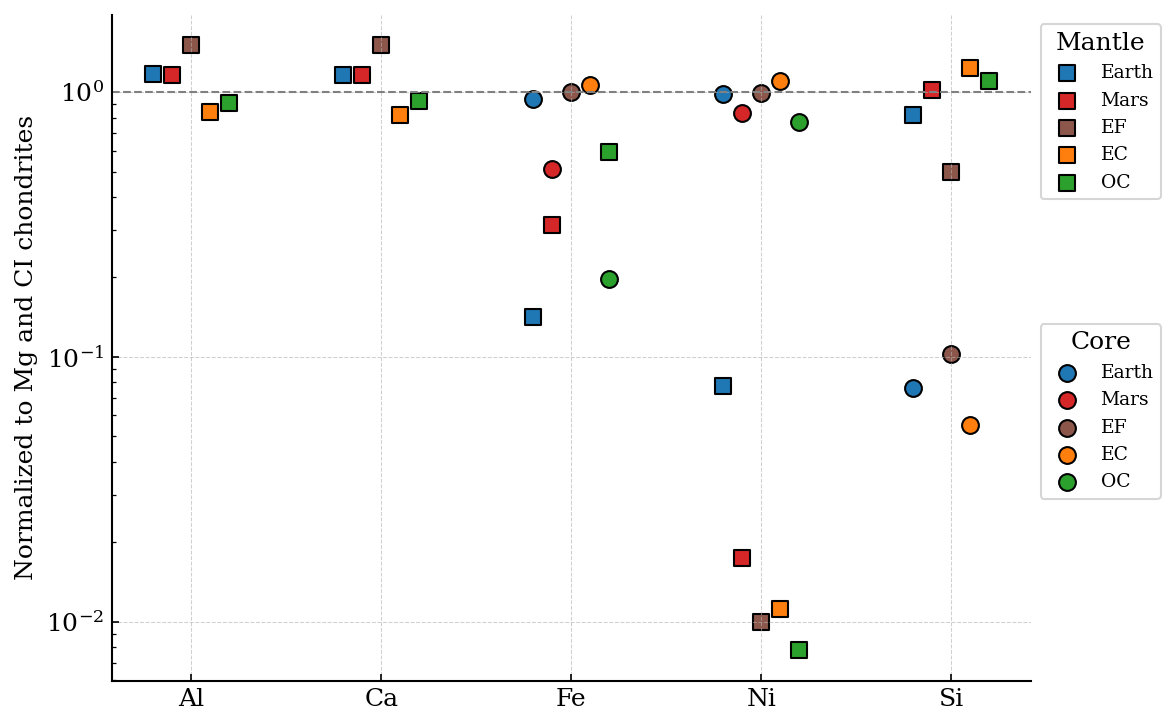

In [6]:
# Elements, keys, and x-axis indices
elements   = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
mantle_keys = ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_keys   = ['Fe', 'Ni', 'Si']
x_idx  = np.arange(len(elements))          # [0,1,2,3,4]
xx_idx = np.array([2, 3, 4])               # Fe, Ni, Si positions

# Build plot datasets: (label, y-values, color, x-positions, marker)
plot_groups = [
    {
        'title'  : 'Mantle',
        'marker' : 's',
        'x_base' : x_idx,
        'data'   : [
            (name, [mantle_CI[name][k] for k in mantle_keys], Colors[name])
            for name in ['Earth', 'Mars', 'EF', 'EC', 'OC']
        ],
    },
    {
        'title'  : 'Core',
        'marker' : 'o',
        'x_base' : xx_idx,
        'data'   : [
            (name, [core_CI[name][k] for k in core_keys], Colors[name])
            for name in ['Earth', 'Mars', 'EF', 'EC', 'OC']
        ],
    },
]

fig, ax = plt.subplots(figsize=(8, 5))
legend_groups = {}

for group in plot_groups:
    offsets = np.linspace(-0.2, 0.2, len(group['data']))
    handles_list = []
    for offset, (label, y, color) in zip(offsets, group['data']):
        sc = ax.scatter(
            group['x_base'] + offset, y,
            label=label, color=color,
            marker=group['marker'], s=65, edgecolor='k', alpha=1
        )
        handles_list.append(sc)
    legend_groups[group['title']] = handles_list

ax.set_yscale('log')
ax.set_xticks(x_idx)
ax.set_xticklabels(elements, fontsize=12)
ax.set_ylabel('Normalized to Mg and CI chondrites', fontsize=12)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grouped legends
labels_list = ['Earth', 'Mars', 'EF', 'EC', 'OC']
leg1 = ax.legend(legend_groups['Mantle'], labels_list, title='Mantle',
                 bbox_to_anchor=(1.0, 1.0), loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend(legend_groups['Core'], labels_list, title='Core',
          bbox_to_anchor=(1.0, 0.55), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# DataFrame for bulk compositions
df_bulk = pd.DataFrame({
    'EF': EF_bulk_mg,
    'EC': EC_bulk_mg,
    'OC': OC_bulk_mg,
    'CI': CI_bulk_mg
})
# 用0填充df_bulk中的NaN
df_bulk = df_bulk.fillna(0)
df_bulk

,EF,EC,OC,CI
MgO,1.000000,1.000000,1.000000,1.000000
Al2O3,0.059488,0.033370,0.036082,0.039658
CaO,0.086858,0.047382,0.053517,0.057905
FeO,0.000000,0.000000,0.498534,0.843874
NiO,0.000460,0.000511,0.000358,0.046009
SiO2,0.483270,1.190060,1.063167,0.970423
Fe,0.843874,0.898519,0.166178,0.000000
Ni,0.045552,0.050623,0.035430,0.000000
Si,0.098983,0.053472,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


In [8]:
# save to CSV
save_file = './Tables/Meteorites_composition.csv'
df_bulk.to_csv(save_file, index=True)

## 5. Summary

| Step | Operation | Output |
|------|-----------|--------|
| 1 | wt% → molar amounts | `EF/EC/OC/CI_bulk_molar` |
| 2 | Normalize to MgO | `EF/EC/OC/CI_bulk_mg` |
| 3 | EF enrichment/depletion corrections | Updated `EF_bulk_mg` |
| 4 | Normalize to Mg & CI | `mantle_CI`, `core_CI` dicts |
| 5 | Spider diagram | CI-normalized comparison plot |
| 6 | Export to CSV | `./Tables/Meteorites_composition.csv` |

The corrected MgO-normalized compositions (`*_bulk_mg`) and CI-normalized dicts (`mantle_CI`, `core_CI`) will be used in subsequent notebooks.

➡️ **Next:** `03_planet_bulk_composition.ipynb`